# DrowSim — BiLSTM Driver Drowsiness Detection
**Dataset:** FL3D (Frame-Level Driver Drowsiness Detection)  
**Model:** BiLSTM + Attention Mechanism  
**Features:** 4 geometric facial features (EAR, MAR, nose angle, eye angle)  
**Classes:** Alert · Microsleep · Yawning

## 1. Imports and Setup

In [17]:
import os
import json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device          : {device}")

PyTorch version : 2.10.0+cpu
CUDA available  : False
Device          : cpu


## 2. Load Dataset
The FL3D dataset contains 53,331 labelled frames from night-time driving videos. Each frame includes 5 facial landmark coordinates and a driver-state label.

In [18]:
import os
import json
import pandas as pd

BASE_PATH = "/kaggle/input/datasets/matjazmuc/frame-level-driver-drowsiness-detection-fl3d/classification_frames"
ALL_JSON  = os.path.join(BASE_PATH, "annotations_all.json")

with open(ALL_JSON, "r") as f:
    all_data = json.load(f)

print(f"Total frames loaded: {len(all_data)}")

rows = []
base_input = "/kaggle/input/datasets/matjazmuc/frame-level-driver-drowsiness-detection-fl3d"

for img_path, info in all_data.items():
    parts = img_path.split("/")
    video_id = parts[2]
    frame_str = parts[3].split(".")[0]
    frame_num = int(frame_str[5:]) if frame_str.startswith("frame") and frame_str[5:].isdigit() else -1
    person_id = int(video_id.split("_")[0][1:]) if video_id.startswith("P") else -1

    rows.append({
        "image_path": os.path.join(base_input, img_path.lstrip("/")),
        "driver_state": info["driver_state"],
        "landmarks": info["landmarks"],
        "video_id": video_id,
        "frame_num": frame_num,
        "person_id": person_id,
    })

df = pd.DataFrame(rows)
print(f"DataFrame shape: {df.shape}")
print("\nClass distribution:")
print(df["driver_state"].value_counts())

Total frames loaded: 53331
DataFrame shape: (53331, 6)

Class distribution:
driver_state
alert         38954
microsleep     8880
yawning        5497
Name: count, dtype: int64


## 3. Feature Extraction
Four geometric features are computed from the 5 facial landmarks supplied in the dataset.  
The landmarks represent: left eye, right eye, nose tip, left mouth corner, right mouth corner.

| Feature | Formula | Meaning |
|---------|---------|---------|
| EAR | eye_height / eye_width | Eye openness |
| MAR | mouth_height / mouth_width | Mouth openness / yawning |
| nose_angle | arctan2(nose − left_eye) | Head tilt |
| eye_angle | arctan2(right_eye − left_eye) | Head roll |

In [19]:
def euclidean(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

def compute_features(landmarks):
    """Compute 4 geometric features from 5 landmark points."""
    try:
        if len(landmarks) != 5:
            return [np.nan, np.nan, np.nan, np.nan]
        p1, p2, p3, p4, p5 = landmarks   # left_eye, right_eye, nose, mouth_L, mouth_R

        EAR       = euclidean(p1, p3) / (euclidean(p1, p2) + 1e-6)
        mouth_h   = euclidean(p3, p4) + euclidean(p3, p5)
        MAR       = mouth_h / (euclidean(p4, p5) + 1e-6)
        nose_vec  = np.array(p3) - np.array(p1)
        nose_angle = float(np.arctan2(nose_vec[1], nose_vec[0]))
        eye_angle  = float(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))
        return [EAR, MAR, nose_angle, eye_angle]
    except Exception:
        return [np.nan, np.nan, np.nan, np.nan]

print("Extracting features...")
feats = df["landmarks"].apply(compute_features)
df["EAR"]        = feats.apply(lambda x: x[0])
df["MAR"]        = feats.apply(lambda x: x[1])
df["nose_angle"] = feats.apply(lambda x: x[2])
df["eye_angle"]  = feats.apply(lambda x: x[3])

before = len(df)
df = df.dropna(subset=["EAR", "MAR", "nose_angle", "eye_angle"])
print(f"Frames after NaN removal: {len(df)} (removed {before - len(df)})")
print("\nFeature statistics:")
print(df[["EAR", "MAR", "nose_angle", "eye_angle"]].describe().round(4))

Extracting features...
Frames after NaN removal: 53331 (removed 0)

Feature statistics:
              EAR         MAR  nose_angle   eye_angle
count  53331.0000  53331.0000  53331.0000  53331.0000
mean       0.7863      1.9531      0.7406     -0.0233
std        0.2645      0.7651      0.2113      0.1219
min        0.1237      1.0003     -2.8198     -2.7744
25%        0.6652      1.7296      0.6083     -0.0950
50%        0.7482      1.8737      0.7337     -0.0316
75%        0.8529      2.0606      0.8584      0.0425
max       20.3593     63.6333      2.0011      1.9138


## 4. Person-Disjoint Train / Val / Test Split
Splitting is done by `person_id` to prevent data leakage — no person appears in more than one split.  
Ratio: **70% train · 15% val · 15% test** (44 unique persons total).

In [20]:
FEATURE_COLS = ["EAR", "MAR", "nose_angle", "eye_angle"]
LABEL_MAP    = {"alert": 0, "microsleep": 1, "yawning": 2}

np.random.seed(42)
persons = df["person_id"].unique()
np.random.shuffle(persons)
n = len(persons)

train_ids = persons[:int(n * 0.70)]
val_ids   = persons[int(n * 0.70):int(n * 0.85)]
test_ids  = persons[int(n * 0.85):]

train_df = df[df["person_id"].isin(train_ids)].reset_index(drop=True)
val_df   = df[df["person_id"].isin(val_ids)].reset_index(drop=True)
test_df  = df[df["person_id"].isin(test_ids)].reset_index(drop=True)

# Verify no overlap
assert len(set(train_df.person_id) & set(val_df.person_id))  == 0
assert len(set(train_df.person_id) & set(test_df.person_id)) == 0
assert len(set(val_df.person_id)   & set(test_df.person_id)) == 0
print("No person overlap between splits — confirmed.")

print(f"\nTrain : {len(train_df):6,} frames | {train_df.person_id.nunique()} persons")
print(f"Val   : {len(val_df):6,} frames | {val_df.person_id.nunique()} persons")
print(f"Test  : {len(test_df):6,} frames | {test_df.person_id.nunique()} persons")

No person overlap between splits — confirmed.

Train : 35,735 frames | 30 persons
Val   :  8,655 frames | 7 persons
Test  :  8,941 frames | 7 persons


## 5. Temporal Sequence Construction
The BiLSTM requires sequences as input. Each sequence contains `seq_len=32` consecutive frames from the same video, labelled with the majority class.  
`stride=8` creates overlapping sequences to increase training data.

In [21]:
def build_sequences(dataframe, seq_len=32, stride=8):
    """Build overlapping fixed-length sequences from per-video frame groups."""
    seq_feats, seq_labels = [], []
    for _, group in dataframe.groupby("video_id"):
        group = group.sort_values("frame_num").reset_index(drop=True)
        if len(group) < seq_len:
            continue
        feats  = group[FEATURE_COLS].values
        states = group["driver_state"].tolist()
        for start in range(0, len(group) - seq_len + 1, stride):
            majority = Counter(states[start:start + seq_len]).most_common(1)[0][0]
            seq_feats.append(feats[start:start + seq_len])
            seq_labels.append(LABEL_MAP[majority])
    return np.array(seq_feats), np.array(seq_labels)

train_X, train_y = build_sequences(train_df)
val_X,   val_y   = build_sequences(val_df)
test_X,  test_y  = build_sequences(test_df)

print(f"Train sequences : {train_X.shape}")
print(f"Val   sequences : {val_X.shape}")
print(f"Test  sequences : {test_X.shape}")
print(f"\nSequence shape  : (batch, time_steps={train_X.shape[1]}, features={train_X.shape[2]})")

Train sequences : (4363, 32, 4)
Val   sequences : (1058, 32, 4)
Test  sequences : (1094, 32, 4)

Sequence shape  : (batch, time_steps=32, features=4)


## 6. Model Architecture — BiLSTM with Attention
- **BiLSTM** captures temporal patterns in both forward and backward directions  
- **Attention** weights each time step by its importance for the final prediction  
- **Focal Loss** addresses class imbalance (alert >> microsleep > yawning)

In [22]:
class DrowsinessDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


class BiLSTM_Attention(nn.Module):
    """Bidirectional LSTM with attention for drowsiness classification."""
    def __init__(self, input_size=4, hidden_size=64, num_layers=2,
                 num_classes=3, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.attention = nn.Linear(hidden_size * 2, 1)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _  = self.lstm(x)                              # (B, T, H*2)
        weights = torch.softmax(self.attention(out), dim=1) # (B, T, 1)
        context = (out * weights).sum(dim=1)                # (B, H*2)
        return self.fc(self.dropout(context))               # (B, num_classes)


class FocalLoss(nn.Module):
    """Focal loss to down-weight easy examples and focus on hard ones."""
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce   = nn.CrossEntropyLoss(reduction="none")(inputs, targets)
        pt   = torch.exp(-ce)
        loss = self.alpha * (1 - pt) ** self.gamma * ce
        return loss.mean()


# Instantiate
model     = BiLSTM_Attention(input_size=4, hidden_size=64).to(device)
criterion = FocalLoss(alpha=1, gamma=2)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(model)

Model parameters: 135,684
BiLSTM_Attention(
  (lstm): LSTM(4, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


## 7. Training with Early Stopping

In [23]:
BATCH_SIZE = 64
EPOCHS     = 30
PATIENCE   = 7
MODEL_PATH = "best_bilstm_privacy.pth"

train_loader = DataLoader(DrowsinessDataset(train_X, train_y), BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(DrowsinessDataset(val_X,   val_y),   BATCH_SIZE)
test_loader  = DataLoader(DrowsinessDataset(test_X,  test_y),  BATCH_SIZE)

best_val_acc = 0.0
wait = 0
history = {"train_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    # --- Train ---
    model.train()
    running_loss = correct = total = 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        out  = model(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_b.size(0)
        correct      += (out.argmax(1) == y_b).sum().item()
        total        += y_b.size(0)
    train_loss = running_loss / total
    train_acc  = correct / total

    # --- Validate ---
    model.eval()
    val_correct = val_total = 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            out = model(X_b.to(device))
            val_correct += (out.argmax(1) == y_b.to(device)).sum().item()
            val_total   += y_b.size(0)
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    tag = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        wait = 0
        torch.save(model.state_dict(), MODEL_PATH)
        tag = "  <-- best saved"
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

    print(f"Epoch {epoch:2d}/{EPOCHS} | loss {train_loss:.4f} | "
          f"train {train_acc:.4f} | val {val_acc:.4f}{tag}")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch  1/30 | loss 0.2785 | train 0.7135 | val 0.6739  <-- best saved
Epoch  2/30 | loss 0.1390 | train 0.8118 | val 0.8535  <-- best saved
Epoch  3/30 | loss 0.1329 | train 0.8247 | val 0.8658  <-- best saved
Epoch  4/30 | loss 0.1387 | train 0.8109 | val 0.8696  <-- best saved
Epoch  5/30 | loss 0.1237 | train 0.8281 | val 0.8459
Epoch  6/30 | loss 0.1273 | train 0.8343 | val 0.8629
Epoch  7/30 | loss 0.1232 | train 0.8354 | val 0.8705  <-- best saved
Epoch  8/30 | loss 0.1160 | train 0.8368 | val 0.8705
Epoch  9/30 | loss 0.1178 | train 0.8364 | val 0.8629
Epoch 10/30 | loss 0.1182 | train 0.8384 | val 0.8507
Epoch 11/30 | loss 0.1148 | train 0.8400 | val 0.8819  <-- best saved
Epoch 12/30 | loss 0.1161 | train 0.8435 | val 0.8800
Epoch 13/30 | loss 0.1100 | train 0.8464 | val 0.8573
Epoch 14/30 | loss 0.1173 | train 0.8441 | val 0.8752
Epoch 15/30 | loss 0.1153 | train 0.8421 | val 0.8762
Epoch 16/30 | loss 0.1126 | train 0.8439 | val 0.8913  <-- best saved
Epoch 17/30 | loss 0.109

## 8. Training Curves

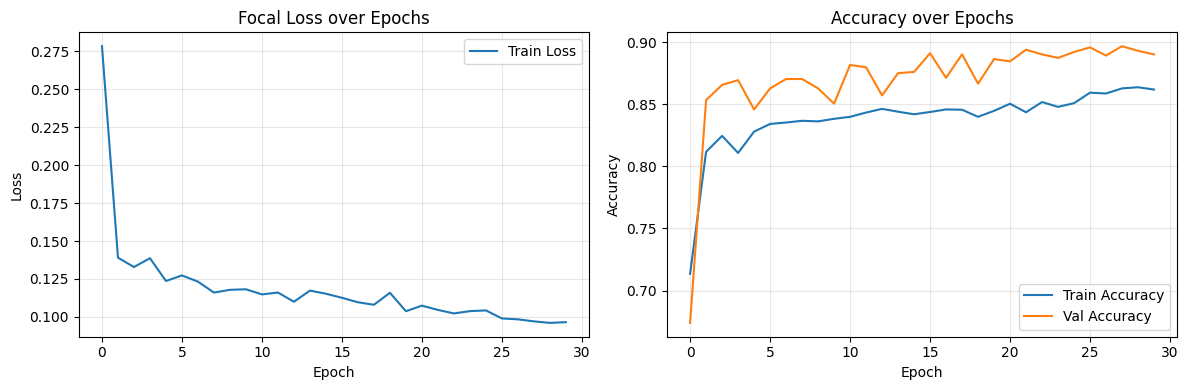

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].set_title("Focal Loss over Epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], label="Train Accuracy")
axes[1].plot(history["val_acc"],   label="Val Accuracy")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Evaluation on Test Set

Classification Report:
              precision    recall  f1-score   support

       alert       0.96      0.96      0.96       844
  microsleep       0.85      0.85      0.85       163
     yawning       0.94      0.94      0.94        87

    accuracy                           0.95      1094
   macro avg       0.92      0.92      0.92      1094
weighted avg       0.95      0.95      0.95      1094



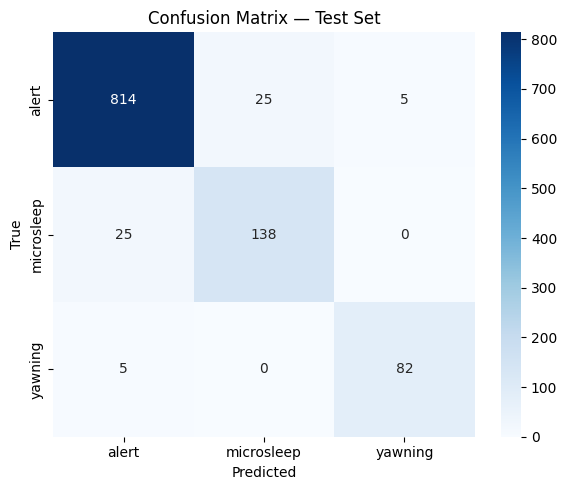

In [25]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        preds = model(X_b.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_b.numpy())

class_names = ["alert", "microsleep", "yawning"]
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Test Set")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.show()

In [35]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()


all_preds, all_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        outputs = model(X_b.to(device))
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_b.numpy())

class_names = ["alert", "microsleep", "yawning"]

acc = accuracy_score(all_labels, all_preds)


precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, average=None
)


precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro"
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted"
)

results_df = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Support": support
})

print(f"Overall Accuracy: {acc:.4f}\n")
print("Per-class Metrics:")
print(results_df.to_string(index=False))

print("\nMacro Average:")
print(f"Precision: {precision_macro:.4f}")
print(f"Recall   : {recall_macro:.4f}")
print(f"F1-Score : {f1_macro:.4f}")

print("\nWeighted Average:")
print(f"Precision: {precision_weighted:.4f}")
print(f"Recall   : {recall_weighted:.4f}")
print(f"F1-Score : {f1_weighted:.4f}")

Overall Accuracy: 0.9452

Per-class Metrics:
     Class  Precision   Recall  F1-Score  Support
     alert   0.964455 0.964455  0.964455      844
microsleep   0.846626 0.846626  0.846626      163
   yawning   0.942529 0.942529  0.942529       87

Macro Average:
Precision: 0.9179
Recall   : 0.9179
F1-Score : 0.9179

Weighted Average:
Precision: 0.9452
Recall   : 0.9452
F1-Score : 0.9452


## 10. Robustness Test — Gaussian Noise
Adding small Gaussian noise (σ = 0.02) to the test features simulates sensor noise from the camera. This checks that the model does not overfit to exact feature values.

In [26]:
noisy_X = test_X + np.random.normal(0, 0.02, test_X.shape)
noisy_loader = DataLoader(DrowsinessDataset(noisy_X, test_y), BATCH_SIZE)

model.eval()
correct = total = 0
with torch.no_grad():
    for X_b, y_b in noisy_loader:
        out = model(X_b.to(device))
        correct += (out.argmax(1) == y_b.to(device)).sum().item()
        total   += y_b.size(0)
noisy_acc = correct / total
print(f"Accuracy on clean test  : {sum(p == l for p,l in zip(all_preds, all_labels)) / len(all_labels):.4f}")
print(f"Accuracy with noise     : {noisy_acc:.4f}")
print(f"Accuracy drop           : {(sum(p == l for p,l in zip(all_preds, all_labels)) / len(all_labels)) - noisy_acc:.4f}")

Accuracy on clean test  : 0.9452
Accuracy with noise     : 0.9461
Accuracy drop           : -0.0009


## 11. Inference Latency
Measures the average time to classify one sequence. Must be well under 500 ms for real-time use.

In [27]:
dummy = torch.randn(1, 32, 4).to(device)
model.eval()

# Warm-up
for _ in range(10):
    _ = model(dummy)

times = []
for _ in range(200):
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = model(dummy)
    times.append(time.perf_counter() - t0)

mean_ms = np.mean(times) * 1000
std_ms  = np.std(times)  * 1000
print(f"Mean latency : {mean_ms:.3f} ms")
print(f"Std  latency : {std_ms:.3f} ms")
print(f"Max  latency : {max(times)*1000:.3f} ms")
print(f"\nReal-time threshold : 500 ms  -->  {'PASS' if mean_ms < 500 else 'FAIL'}")

Mean latency : 1.771 ms
Std  latency : 0.154 ms
Max  latency : 2.728 ms

Real-time threshold : 500 ms  -->  PASS


## 12. Save Final Model

In [30]:
MODEL_PATH2 = "BiLSTM4.pth"
torch.save(model.state_dict(), MODEL_PATH2)

print(f"Model saved to: {MODEL_PATH2}")
print(f"File size     : {os.path.getsize(MODEL_PATH2) / 1024:.1f} KB")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Model saved to: BiLSTM4.pth
File size     : 536.1 KB
